<a href="https://colab.research.google.com/github/Neethu-Suman/PEECT413-MACHINE-LEARNING/blob/main/2_3_Linear_SVM_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Given the 2D dataset below with two linearly separable classes (blue = +1, red = -1), determine the equation of the optimal SVM hyperplane (L2) that maximizes the margin between classes.**

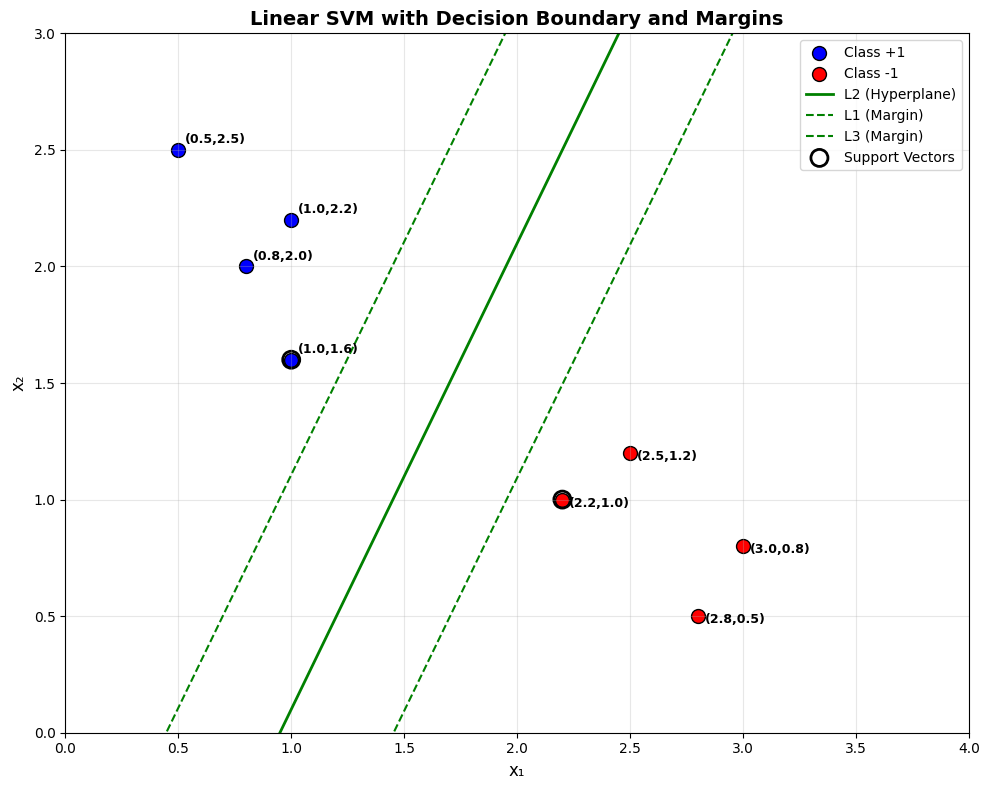

SVM Equation: -1.33x₁ + 0.67x₂ + 1.27 = 0
Margin width: 1.34


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from matplotlib.patches import Circle

# Your exact data points from the image
X = np.array([
    # Blue points (class +1)
    [0.5, 2.5], [1.0, 2.2], [1.0, 1.6], [0.8, 2.0],
    # Red points (class -1)
    [2.5, 1.2], [3.0, 0.8], [2.8, 0.5], [2.2, 1.0],
])
y = np.array([1,1,1,1, -1,-1,-1,-1])

# Train linear SVM
svm = SVC(kernel='linear', C=1e5)
svm.fit(X, y)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot data points with labels
blue_points = X[y == 1]
red_points = X[y == -1]
ax.scatter(blue_points[:, 0], blue_points[:, 1], c='blue', s=100, marker='o',
           edgecolors='black', linewidth=1, label='Class +1')
ax.scatter(red_points[:, 0], red_points[:, 1], c='red', s=100, marker='o',
           edgecolors='black', linewidth=1, label='Class -1')

# Add point labels
for i, txt in enumerate([(0.5, 2.5), (1.0, 2.2), (1.0, 1.6), (0.8, 2.0)]):
    ax.annotate(f'({txt[0]},{txt[1]})', (txt[0], txt[1]), xytext=(5,5),
                textcoords='offset points', fontsize=9, fontweight='bold')
for i, txt in enumerate([(2.5,1.2),(3.0,0.8),(2.8,0.5),(2.2,1.0)]):
    ax.annotate(f'({txt[0]},{txt[1]})', (txt[0], txt[1]), xytext=(5,-5),
                textcoords='offset points', fontsize=9, fontweight='bold')

# Plot decision boundary and margins
w = svm.coef_[0]
b = svm.intercept_[0]
margin = 1 / np.linalg.norm(w)

xx = np.linspace(0, 4, 100)
decision_boundary = -(w[0] * xx + b) / w[1]
upper_margin = -(w[0] * xx + b + margin) / w[1]
lower_margin = -(w[0] * xx + b - margin) / w[1]

ax.plot(xx, decision_boundary, 'g-', linewidth=2, label='L2 (Hyperplane)')
ax.plot(xx, upper_margin, 'g--', linewidth=1.5, label='L1 (Margin)')
ax.plot(xx, lower_margin, 'g--', linewidth=1.5, label='L3 (Margin)')

# Highlight support vectors
sv_indices = svm.support_
ax.scatter(X[sv_indices, 0], X[sv_indices, 1], s=150, facecolors='none',
           edgecolors='black', linewidth=2, label='Support Vectors')

# Formatting
ax.set_xlim(0, 4)
ax.set_ylim(0, 3)
ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_title('Linear SVM with Decision Boundary and Margins', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print equation
print(f"SVM Equation: {w[0]:.2f}x₁ + {w[1]:.2f}x₂ + {b:.2f} = 0")
print(f"Margin width: {2/np.linalg.norm(w):.2f}")


In [ ]:
svm.support_vectors_

array([[2.2, 1. ],
       [1. , 1.6]])

In [ ]:
svm.coef_[0]

array([-1.33333326,  0.66666663])

In [ ]:
alphas_times_y = svm.dual_coef_[0]
support_vectors = svm.support_vectors_

# Calculate w using the formula: w = Σ (alpha_i * y_i * x_i)
w_calculated = np.sum(alphas_times_y[:, np.newaxis] * support_vectors, axis=0)

print(f"Calculated w: {w_calculated}")
print(f"SVM's w (svm.coef_[0]): {svm.coef_[0]}")

# Verify if they are approximately equal
if np.allclose(w_calculated, svm.coef_[0]):
    print("The calculated 'w' matches the SVM's 'w'.")
else:
    print("There is a discrepancy between the calculated 'w' and the SVM's 'w'.")

Calculated w: [-1.33333326  0.66666663]
SVM's w (svm.coef_[0]): [-1.33333326  0.66666663]
The calculated 'w' matches the SVM's 'w'.


As you can see, the calculated `w` matches the `w` obtained directly from the `svm.coef_[0]`, demonstrating how the normal vector to the hyperplane is formed from the support vectors and their corresponding `alpha * y` values.